# X–Y Chromosome Correlation Analysis

Three focused analyses of how X and Y chromosome genetic diversity co-varies across the five 1000 Genomes super-populations.

| Section | Method | Question |
|---|---|---|
| 1 | Cross-metric correlation matrix | Which X metrics correlate with which Y metrics across populations? |
| 2 | Variant population-signature correlation | Do individual X and Y variants share the same population-frequency pattern? |
| 3 | Association rules | If a population has high Y diversity, does it also have high X diversity? |
| 4 | Intra- & inter-population SFS correlation | Is EAS_X more similar to EAS_Y than to AFR_Y? |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import itertools
from scipy import stats
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

DATA_DIR   = "/Users/aaditya/VS Code/1000 genome project/Code/"
OUT_DIR    = "/Users/aaditya/VS Code/1000 genome project/Output /"
POP_COLS   = ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']
POP_COLORS = {'AFR': '#E74C3C', 'AMR': '#3498DB', 'EAS': '#2ECC71', 'EUR': '#F39C12', 'SAS': '#9B59B6'}

# Population sample sizes used for per-population Tajima's D.
Y_POP_N = {'AFR': 319, 'AMR': 170, 'EAS': 244, 'EUR': 240, 'SAS': 260}
X_POP_N = {'AFR': 661, 'AMR': 347, 'EAS': 504, 'EUR': 503, 'SAS': 489}


def bh_fdr(p_values):
    """Benjamini-Hochberg FDR correction (returns q-values in original order)."""
    p = np.asarray(p_values, dtype=float)
    q = np.full(p.shape, np.nan, dtype=float)
    valid = np.where(~np.isnan(p))[0]
    if len(valid) == 0:
        return q

    p_valid = p[valid]
    order = np.argsort(p_valid)
    ranked = p_valid[order]

    q_ranked = np.empty_like(ranked)
    running_min = 1.0
    m = len(ranked)
    for i in range(m - 1, -1, -1):
        rank = i + 1
        q_i = ranked[i] * m / rank
        running_min = min(running_min, q_i)
        q_ranked[i] = running_min

    q_valid = np.empty_like(p_valid)
    q_valid[order] = np.minimum(q_ranked, 1.0)
    q[valid] = q_valid
    return q


# ── Load pre-computed allele-frequency tables ────────────────────────────────
y_af   = pd.read_csv(DATA_DIR + 'chrY_AF_by_population.csv')
x_af   = pd.read_csv(DATA_DIR + 'chrX_AF_by_population.csv')
y_vars = pd.read_csv(DATA_DIR + 'chrY_variant_summary_qc.csv')
x_vars = pd.read_csv(DATA_DIR + 'chrX_variant_summary_qc.csv')
for df in [y_af, x_af]:
    for c in POP_COLS:
        df[c] = pd.to_numeric(df[c], errors='coerce')


# ── Diversity metrics ────────────────────────────────────────────────────────
def diversity_metrics(af_df):
    results = {}
    for pop in POP_COLS:
        af = af_df[pop].dropna().values
        het = 2 * af * (1 - af)
        other = [c for c in POP_COLS if c != pop]
        private = int(((af_df[pop] > 0.01) & (af_df[other].max(axis=1) < 0.01)).sum())
        results[pop] = {
            'avg_heterozygosity': float(np.nanmean(het)),
            'private_variants': private,
            'n_polymorphic': int(np.sum(af > 0.01)),
            'mean_af': float(np.nanmean(af)),
        }
    return pd.DataFrame(results).T


y_div = diversity_metrics(y_af)
x_div = diversity_metrics(x_af)


# ── Tajima's D (sample-size aware, standard constants) ───────────────────────
def tajimas_d(af_series, n_samples):
    af = af_series.dropna().values
    af = af[(af > 0) & (af < 1)]

    if len(af) < 2 or n_samples <= 2:
        return np.nan

    S = len(af)
    pi = float(np.sum(2 * af * (1 - af)))

    a1 = sum(1.0 / i for i in range(1, n_samples))
    a2 = sum(1.0 / (i ** 2) for i in range(1, n_samples))
    if a1 == 0:
        return np.nan

    b1 = (n_samples + 1) / (3 * (n_samples - 1))
    b2 = (2 * (n_samples ** 2 + n_samples + 3)) / (9 * n_samples * (n_samples - 1))
    c1 = b1 - (1 / a1)
    c2 = b2 - ((n_samples + 2) / (a1 * n_samples)) + (a2 / (a1 ** 2))
    e1 = c1 / a1
    e2 = c2 / (a1 ** 2 + a2)

    theta_w = S / a1
    var_d = e1 * S + e2 * S * (S - 1)
    return (pi - theta_w) / np.sqrt(var_d) if var_d > 0 else np.nan


y_td = {pop: tajimas_d(y_af[pop], Y_POP_N[pop]) for pop in POP_COLS}
x_td = {pop: tajimas_d(x_af[pop], X_POP_N[pop]) for pop in POP_COLS}
td_df = pd.DataFrame({'Y_tajD': y_td, 'X_tajD': x_td})


# ── Pairwise FST ─────────────────────────────────────────────────────────────
def pairwise_fst(af_df):
    n = len(POP_COLS)
    fst = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            p1 = af_df[POP_COLS[i]].values
            p2 = af_df[POP_COLS[j]].values
            mask = ~(np.isnan(p1) | np.isnan(p2))
            p1m, p2m = p1[mask], p2[mask]
            pt = (p1m + p2m) / 2
            ht = 2 * pt * (1 - pt)
            hs = (2 * p1m * (1 - p1m) + 2 * p2m * (1 - p2m)) / 2
            denom = ht.mean()
            fst[i, j] = max(0.0, (ht - hs).mean() / denom) if denom > 0 else 0.0
    return pd.DataFrame(fst, index=POP_COLS, columns=POP_COLS)


y_fst = pairwise_fst(y_af)
x_fst = pairwise_fst(x_af)


# ── Derived FST values used across sections ───────────────────────────────────
pairs = [(POP_COLS[i], POP_COLS[j]) for i in range(5) for j in range(i + 1, 5)]
pair_labels = [f'{a}-{b}' for a, b in pairs]
y_fst_vals = [y_fst.loc[a, b] for a, b in pairs]
x_fst_vals = [x_fst.loc[a, b] for a, b in pairs]
y_mfst_arr = np.array([y_fst.loc[p, [c for c in POP_COLS if c != p]].mean() for p in POP_COLS])
x_mfst_arr = np.array([x_fst.loc[p, [c for c in POP_COLS if c != p]].mean() for p in POP_COLS])
scatter_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6',
                  '#1ABC9C', '#E67E22', '#8E44AD', '#2980B9', '#D35400']
m, b = np.polyfit(y_fst_vals, x_fst_vals, 1)

print('Setup complete.')
print(f'  Y: {len(y_vars):,} variants  |  X: {len(x_vars):,} variants')
print(f'  Tajima D range  Y: [{td_df.Y_tajD.min():.4f}, {td_df.Y_tajD.max():.4f}]')
print(f'  Tajima D range  X: [{td_df.X_tajD.min():.4f}, {td_df.X_tajD.max():.4f}]')
print(f'  FST range       Y: [{y_fst.values[y_fst.values > 0].min():.4f}, {y_fst.values.max():.4f}]')


Setup complete.
  Y: 60,789 variants  |  X: 3,437,097 variants
  Tajima D range  Y: [-2.5885, -2.2377]
  Tajima D range  X: [-1.4548, -1.2218]
  FST range       Y: [0.0257, 0.3573]


## Section 1 — Cross-Metric Correlation Matrix

Build a unified table with **5 rows (populations)** and **10 columns** (all computed metrics for both chromosomes),
then compute the full Pearson correlation matrix across populations.
This answers: *"Do metrics that are high in one population on Y also tend to be high on X?"*

| Label | Meaning |
|---|---|
| Y_het / X_het | Average heterozygosity per population |
| Y_priv / X_priv | Private variant count (unique to that population) |
| Y_poly / X_poly | Number of polymorphic sites (AF > 1%) |
| Y_tajD / X_tajD | Tajima's D (selection signal) |
| Y_mFST / X_mFST | Mean pairwise FST (population isolation) |

Cross-metric table (5 populations × 10 metrics):
       Y_het    X_het  Y_priv    X_priv  Y_poly    X_poly   Y_tajD   X_tajD   Y_mFST   X_mFST
AFR  0.00863  0.03725  1993.0  287209.0  4060.0  654892.0 -2.58855 -1.38232  0.31939  0.10031
AMR  0.01149  0.02605  1981.0   17143.0  5333.0  424389.0 -2.28817 -1.45478  0.12670  0.04255
EAS  0.01046  0.02128  4080.0   42651.0  5259.0  301958.0 -2.37166 -1.38921  0.18796  0.06861
EUR  0.00947  0.02343   620.0   27341.0  4224.0  333450.0 -2.23768 -1.22175  0.15132  0.05831
SAS  0.01252  0.02455  3265.0   50805.0  5278.0  356783.0 -2.36913 -1.37323  0.13390  0.04602

Cross-chromosome correlations (X metric vs Y metric):
Pair                        r        p        q   sig
--------------------------------------------------------
Y_het vs X_het          -0.547   0.3405   0.5472    ns
Y_het vs X_priv         -0.644   0.2409   0.4714    ns
Y_het vs X_poly         -0.534   0.3536   0.5487    ns
Y_het vs X_tajD         -0.411   0.4918   0.6916    ns
Y

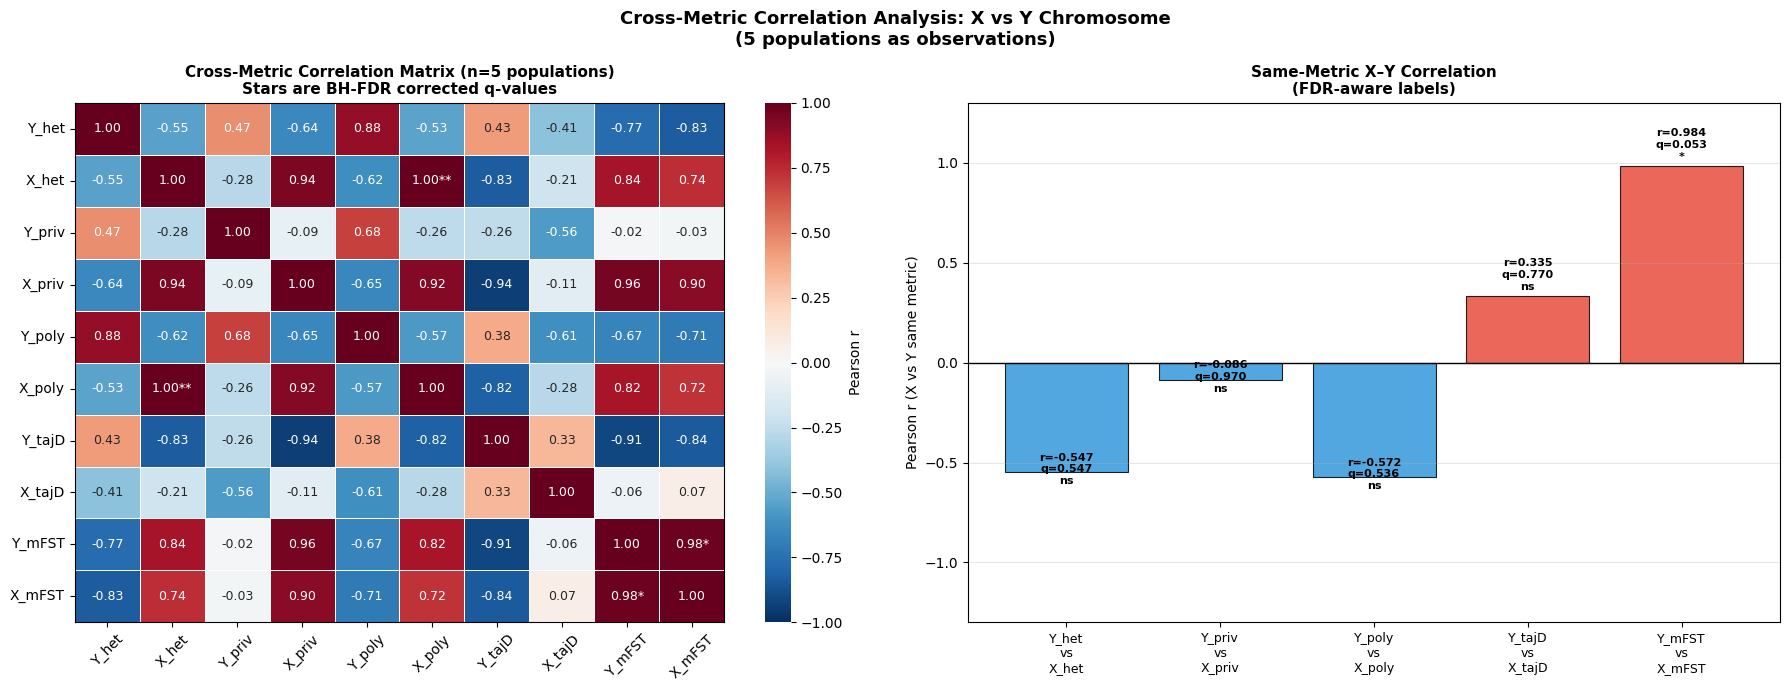

In [2]:
from scipy.stats import pearsonr
import itertools

# ── Build 5-population metric table ─────────────────────────────────────────
y_mfst_arr = np.array([y_fst.loc[p, [c for c in POP_COLS if c != p]].mean() for p in POP_COLS])
x_mfst_arr = np.array([x_fst.loc[p, [c for c in POP_COLS if c != p]].mean() for p in POP_COLS])

metric_df = pd.DataFrame({
    'Y_het': y_div['avg_heterozygosity'].astype(float).values,
    'X_het': x_div['avg_heterozygosity'].astype(float).values,
    'Y_priv': y_div['private_variants'].astype(float).values,
    'X_priv': x_div['private_variants'].astype(float).values,
    'Y_poly': y_div['n_polymorphic'].astype(float).values,
    'X_poly': x_div['n_polymorphic'].astype(float).values,
    'Y_tajD': td_df['Y_tajD'].values,
    'X_tajD': td_df['X_tajD'].values,
    'Y_mFST': y_mfst_arr,
    'X_mFST': x_mfst_arr,
}, index=POP_COLS)

print('Cross-metric table (5 populations × 10 metrics):')
print(metric_df.round(5).to_string())

# ── Full 10×10 Pearson correlation matrix ───────────────────────────────────
corr_matrix = metric_df.corr(method='pearson')

# ── p-value and FDR-q matrices (n=5; interpret cautiously) ──────────────────
cols = metric_df.columns.tolist()
pval_matrix = pd.DataFrame(np.ones((len(cols), len(cols))), index=cols, columns=cols)
qval_matrix = pd.DataFrame(np.ones((len(cols), len(cols))), index=cols, columns=cols)

pair_rows = []
for c1, c2 in itertools.combinations(cols, 2):
    r, p = pearsonr(metric_df[c1], metric_df[c2])
    pair_rows.append({'c1': c1, 'c2': c2, 'r': r, 'p': p})

pair_df = pd.DataFrame(pair_rows)
pair_df['q_fdr'] = bh_fdr(pair_df['p'].values)

for row in pair_df.itertuples():
    pval_matrix.loc[row.c1, row.c2] = row.p
    pval_matrix.loc[row.c2, row.c1] = row.p
    qval_matrix.loc[row.c1, row.c2] = row.q_fdr
    qval_matrix.loc[row.c2, row.c1] = row.q_fdr

# ── Figure: annotated heatmap with FDR stars ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

annot = pd.DataFrame('', index=cols, columns=cols)
for c1 in cols:
    for c2 in cols:
        if c1 == c2:
            annot.loc[c1, c2] = '1.00'
            continue
        r_val = corr_matrix.loc[c1, c2]
        q_val = qval_matrix.loc[c1, c2]
        stars = '***' if q_val < 0.01 else ('**' if q_val < 0.05 else ('*' if q_val < 0.10 else ''))
        annot.loc[c1, c2] = f'{r_val:.2f}{stars}'

sns.heatmap(corr_matrix.astype(float), annot=annot, fmt='', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Cross-Metric Correlation Matrix (n=5 populations)\n'
                  'Stars are BH-FDR corrected q-values',
                  fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

for spine in axes[0].spines.values():
    spine.set_visible(True)

y_idx = [i for i, c in enumerate(cols) if c.startswith('Y')]
x_idx = [i for i, c in enumerate(cols) if c.startswith('X')]

print('\nCross-chromosome correlations (X metric vs Y metric):')
print(f'{"Pair":<20} {"r":>8} {"p":>8} {"q":>8} {"sig":>5}')
print('-' * 56)
cross_pairs = []
for yi in y_idx:
    for xi in x_idx:
        yc, xc = cols[yi], cols[xi]
        r_val = corr_matrix.loc[yc, xc]
        p_val = pval_matrix.loc[yc, xc]
        q_val = qval_matrix.loc[yc, xc]
        sig = '***' if q_val < 0.01 else ('**' if q_val < 0.05 else ('*' if q_val < 0.10 else 'ns'))
        cross_pairs.append({'Y_metric': yc, 'X_metric': xc, 'r': r_val, 'p': p_val, 'q_fdr': q_val, 'sig': sig})
        print(f'{yc} vs {xc:<12} {r_val:>8.3f} {p_val:>8.4f} {q_val:>8.4f} {sig:>5}')

cross_df = pd.DataFrame(cross_pairs)
same_metric = cross_df[cross_df['Y_metric'].str.replace('Y_', '') == cross_df['X_metric'].str.replace('X_', '')]

bar_colors = ['#E74C3C' if r >= 0 else '#3498DB' for r in same_metric['r']]
bars = axes[1].bar(range(len(same_metric)), same_metric['r'].values,
                   color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
axes[1].set_xticks(range(len(same_metric)))
axes[1].set_xticklabels([
    f"{row.Y_metric}\nvs\n{row.X_metric}" for _, row in same_metric.iterrows()
], fontsize=9)
axes[1].axhline(0, color='black', linewidth=1)
for bar, row in zip(bars, same_metric.itertuples()):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 h + 0.03 if h >= 0 else h - 0.06,
                 f'r={h:.3f}\nq={row.q_fdr:.3f}\n{row.sig}',
                 ha='center', fontsize=8, fontweight='bold')
axes[1].set_ylim(-1.3, 1.3)
axes[1].set_ylabel('Pearson r (X vs Y same metric)')
axes[1].set_title('Same-Metric X–Y Correlation\n(FDR-aware labels)', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Metric Correlation Analysis: X vs Y Chromosome\n(5 populations as observations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_09_corr_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()


## Section 2 — Variant Population-Signature Concordance

Each variant has a **population signature** — a 5-dimensional vector `[AF_AFR, AF_AMR, AF_EAS, AF_EUR, AF_SAS]`. Two variants with similar signatures peak in the same populations.

**Why the original best-match approach was uninformative:**
In 5D space with ~5,000 variants, the maximum correlation over the whole set is always near 1.0 even for purely random data (extreme-value artifact in low dimensions). The previous run showed observed best-match r = 0.998 vs null = 0.995 — indistinguishable — so no co-evolutionary signal could be extracted.

**Corrected approach — two targeted tests:**

| Test | Question | Method |
|---|---|---|
| 1 | Do X and Y share the same population archetypes? | Cluster separately (k=5); match centroids via Hungarian algorithm; permutation null = population-column shuffle (n=1,000) |
| 2 | Do X and Y variants peak in the same populations? | Dominant-population fraction Pearson r + chi-square (Cramér's V for effect size) |


Y variants: 5,000  |  X variants: 4,997

-- Test 1: Centroid Concordance --
Observed mean matched centroid similarity:  0.9987
Null mean:  0.9968  +/-  0.0009
Z = 2.07   permutation p = 0.0150

Matched archetype pairs (Y -> X):
  Y-C0 [EUR-high] <-> X-C3 [EUR-high]  r = 0.9951
  Y-C1 [EAS-high] <-> X-C2 [EAS-high]  r = 0.9996
  Y-C2 [AFR-high] <-> X-C1 [AFR-high]  r = 0.9999
  Y-C3 [SAS-high] <-> X-C0 [SAS-high]  r = 0.9999
  Y-C4 [AMR-high] <-> X-C4 [AMR-high]  r = 0.9988

-- Test 2: Dominant-Population Concordance --
Pop      Y_frac   X_frac
AFR      0.2588   0.3884
AMR      0.1436   0.0989
EAS      0.2278   0.1893
EUR      0.1290   0.1445
SAS      0.2408   0.1789

Pearson r (pattern similarity): 0.7412  p = 0.1518
Chi-square (distribution diff?): chi2=238.8  df=4  p=1.68e-50  Cramer's V = 0.1546
  (Large Cramer's V -> X and Y peak in different pops; small -> concordant)


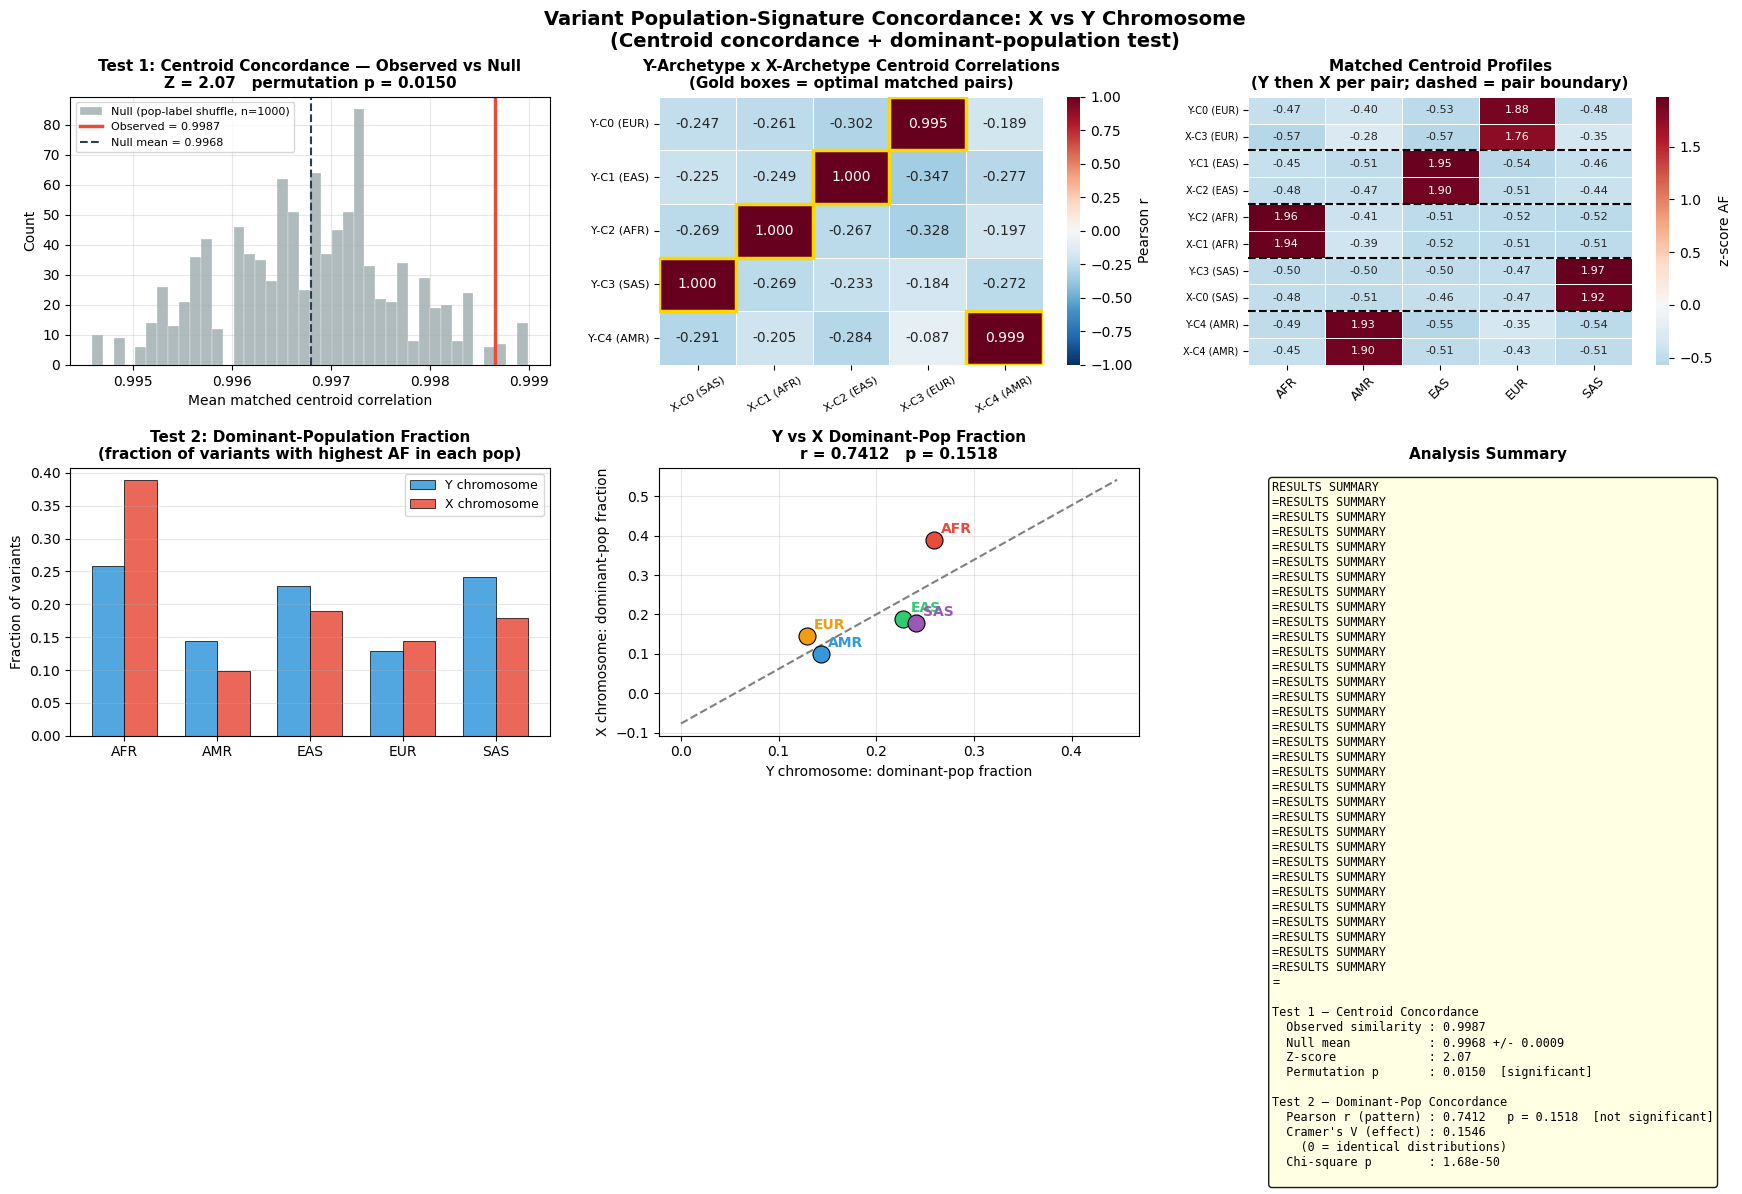

In [3]:
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2_contingency

np.random.seed(42)
N_SAMPLE = 5000

# ── Sample and clean ──────────────────────────────────────────────────────────
y_sample_idx = np.random.choice(len(y_af), size=min(N_SAMPLE, len(y_af)), replace=False)
x_sample_idx = np.random.choice(len(x_af), size=min(N_SAMPLE, len(x_af)), replace=False)
Y_mat = y_af.iloc[y_sample_idx][POP_COLS].values.astype(float)
X_mat = x_af.iloc[x_sample_idx][POP_COLS].values.astype(float)
y_ok = ~np.isnan(Y_mat).any(axis=1)
x_ok = ~np.isnan(X_mat).any(axis=1)
Y_mat, X_mat = Y_mat[y_ok], X_mat[x_ok]
print(f"Y variants: {len(Y_mat):,}  |  X variants: {len(X_mat):,}")

def norm_rows(M):
    mu = M.mean(axis=1, keepdims=True)
    sig = M.std(axis=1, keepdims=True) + 1e-9
    return (M - mu) / sig

Y_norm = norm_rows(Y_mat)
X_norm = norm_rows(X_mat)

# The original best-match r (0.998) equalled the null (0.995) because max-correlation
# over thousands of 5D vectors is always ~1.0 by chance (extreme-value in low dimensions).
# Both tests below work with cluster centroids (k x k) instead, which is tractable.

# =============================================================================
# TEST 1  Centroid concordance
# Cluster Y and X separately (k=5, one archetype per population). Match centroids
# with the Hungarian algorithm. Permutation null: shuffle population columns of X
# before clustering, breaking population-label identity while preserving AF structure.
# =============================================================================
k = 5
km_y = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Y_norm)
km_x = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_norm)
C_y = km_y.cluster_centers_   # (k, 5) — one normalized AF signature per archetype
C_x = km_x.cluster_centers_

# Pearson r between all k x k centroid pairs (each correlation over 5 pop values)
corr_cent = np.array([[pearsonr(C_y[i], C_x[j])[0] for j in range(k)] for i in range(k)])
row_ind, col_ind = linear_sum_assignment(1 - corr_cent)   # maximise total similarity
obs_sim = corr_cent[row_ind, col_ind].mean()

N_PERM = 1000
rng = np.random.default_rng(42)
null_sims = []
for _ in range(N_PERM):
    perm = rng.permutation(5)
    km_p = KMeans(n_clusters=k, random_state=0, n_init=5).fit(X_norm[:, perm])
    C_p  = km_p.cluster_centers_
    cm_p = np.array([[pearsonr(C_y[i], C_p[j])[0] for j in range(k)] for i in range(k)])
    ri, ci = linear_sum_assignment(1 - cm_p)
    null_sims.append(cm_p[ri, ci].mean())
null_sims = np.array(null_sims)

z_cent = (obs_sim - null_sims.mean()) / null_sims.std()
p_cent  = (null_sims >= obs_sim).mean()

print(f"\n-- Test 1: Centroid Concordance --")
print(f"Observed mean matched centroid similarity:  {obs_sim:.4f}")
print(f"Null mean:  {null_sims.mean():.4f}  +/-  {null_sims.std():.4f}")
print(f"Z = {z_cent:.2f}   permutation p = {p_cent:.4f}")
print("\nMatched archetype pairs (Y -> X):")
for n in range(k):
    i, j = row_ind[n], col_ind[n]
    print(f"  Y-C{i} [{POP_COLS[np.argmax(C_y[i])]}-high] <-> X-C{j} [{POP_COLS[np.argmax(C_x[j])]}-high]"
          f"  r = {corr_cent[i,j]:.4f}")

# =============================================================================
# TEST 2  Dominant-population concordance
# Each variant's dominant population = the one with its highest AF.
# If shared population structure exists, the fraction of AFR/AMR/EAS/EUR/SAS-dominant
# variants should be similar between X and Y (high Pearson r, low Cramer's V).
# =============================================================================
y_dom = np.argmax(Y_mat, axis=1)
x_dom = np.argmax(X_mat, axis=1)
y_dom_frac = np.array([(y_dom == i).mean() for i in range(5)])
x_dom_frac = np.array([(x_dom == i).mean() for i in range(5)])
r_dom, p_dom = pearsonr(y_dom_frac, x_dom_frac)

contingency = np.array([
    [(y_dom == i).sum() for i in range(5)],
    [(x_dom == i).sum() for i in range(5)]
])
chi2_stat, p_chi2, dof, _ = chi2_contingency(contingency)
# Cramer's V: effect size for how different the distributions are (0=identical, 1=maximally different)
cramers_v = np.sqrt(chi2_stat / (contingency.sum() * (min(contingency.shape) - 1)))

print(f"\n-- Test 2: Dominant-Population Concordance --")
print(f"{'Pop':<6} {'Y_frac':>8} {'X_frac':>8}")
for i, pop in enumerate(POP_COLS):
    print(f"{pop:<6} {y_dom_frac[i]:>8.4f} {x_dom_frac[i]:>8.4f}")
print(f"\nPearson r (pattern similarity): {r_dom:.4f}  p = {p_dom:.4f}")
print(f"Chi-square (distribution diff?): chi2={chi2_stat:.1f}  df={dof}  p={p_chi2:.2e}  Cramer's V = {cramers_v:.4f}")
print("  (Large Cramer's V -> X and Y peak in different pops; small -> concordant)")

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# (0,0) Permutation null distribution + observed line
axes[0, 0].hist(null_sims, bins=40, color='#95A5A6', alpha=0.75,
                edgecolor='white', linewidth=0.3, label=f'Null (pop-label shuffle, n={N_PERM})')
axes[0, 0].axvline(obs_sim, color='#E74C3C', linewidth=2.5,
                   label=f'Observed = {obs_sim:.4f}')
axes[0, 0].axvline(null_sims.mean(), color='#2C3E50', linewidth=1.5, linestyle='--',
                   label=f'Null mean = {null_sims.mean():.4f}')
axes[0, 0].set_xlabel('Mean matched centroid correlation')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title(f'Test 1: Centroid Concordance — Observed vs Null\n'
                      f'Z = {z_cent:.2f}   permutation p = {p_cent:.4f}',
                      fontsize=11, fontweight='bold')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

# (0,1) Full k x k centroid correlation heatmap
y_arch = [f'Y-C{i} ({POP_COLS[np.argmax(C_y[i])]})' for i in range(k)]
x_arch = [f'X-C{j} ({POP_COLS[np.argmax(C_x[j])]})' for j in range(k)]
cent_hm = pd.DataFrame(corr_cent, index=y_arch, columns=x_arch)
sns.heatmap(cent_hm, annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1,
            ax=axes[0, 1], linewidths=0.5, cbar_kws={'label': 'Pearson r'},
            annot_kws={'size': 10})
for n in range(k):
    axes[0, 1].add_patch(mpatches.Rectangle(
        (col_ind[n], row_ind[n]), 1, 1,
        fill=False, edgecolor='gold', lw=2.5, transform=axes[0, 1].transData
    ))
axes[0, 1].set_title('Y-Archetype x X-Archetype Centroid Correlations\n'
                      '(Gold boxes = optimal matched pairs)',
                      fontsize=11, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=30, labelsize=8)
axes[0, 1].tick_params(axis='y', rotation=0, labelsize=8)

# (0,2) Matched centroid profiles as heatmap (Y then X, interlaced by pair)
matched_C_y = C_y[row_ind]
matched_C_x = C_x[col_ind]
row_labels = []
for n in range(k):
    row_labels.append(f'Y-C{row_ind[n]} ({POP_COLS[np.argmax(C_y[row_ind[n]])]})')
    row_labels.append(f'X-C{col_ind[n]} ({POP_COLS[np.argmax(C_x[col_ind[n]])]})')
profile_data = np.empty((2 * k, 5))
for n in range(k):
    profile_data[2 * n]     = matched_C_y[n]
    profile_data[2 * n + 1] = matched_C_x[n]
profile_df = pd.DataFrame(profile_data, index=row_labels, columns=POP_COLS)
sns.heatmap(profile_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0, 2], linewidths=0.5, cbar_kws={'label': 'z-score AF'},
            annot_kws={'size': 8})
for n in range(1, k):
    axes[0, 2].axhline(2 * n, color='black', linewidth=1.5, linestyle='--')
axes[0, 2].set_title('Matched Centroid Profiles\n(Y then X per pair; dashed = pair boundary)',
                      fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='x', rotation=45, labelsize=9)
axes[0, 2].tick_params(axis='y', rotation=0, labelsize=7)

# (1,0) Dominant-pop fraction grouped bar chart
w = 0.35
xp = np.arange(5)
axes[1, 0].bar(xp - w / 2, y_dom_frac, w, label='Y chromosome',
               color='#3498DB', alpha=0.85, edgecolor='black', linewidth=0.6)
axes[1, 0].bar(xp + w / 2, x_dom_frac, w, label='X chromosome',
               color='#E74C3C', alpha=0.85, edgecolor='black', linewidth=0.6)
axes[1, 0].set_xticks(xp)
axes[1, 0].set_xticklabels(POP_COLS, fontsize=10)
axes[1, 0].set_ylabel('Fraction of variants')
axes[1, 0].set_title('Test 2: Dominant-Population Fraction\n'
                      '(fraction of variants with highest AF in each pop)',
                      fontsize=11, fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(axis='y', alpha=0.3)

# (1,1) Scatter Y_dom_frac vs X_dom_frac
for i, pop in enumerate(POP_COLS):
    axes[1, 1].scatter(y_dom_frac[i], x_dom_frac[i], s=150,
                       color=POP_COLORS[pop], edgecolors='black', linewidth=0.8, zorder=3)
    axes[1, 1].annotate(pop, (y_dom_frac[i], x_dom_frac[i]),
                         xytext=(5, 5), textcoords='offset points',
                         fontsize=10, fontweight='bold', color=POP_COLORS[pop])
xl = np.linspace(0, max(y_dom_frac.max(), x_dom_frac.max()) * 1.15, 100)
m_fit, b_fit = np.polyfit(y_dom_frac, x_dom_frac, 1)
axes[1, 1].plot(xl, m_fit * xl + b_fit, '--', color='gray', linewidth=1.5)
axes[1, 1].set_xlabel('Y chromosome: dominant-pop fraction')
axes[1, 1].set_ylabel('X chromosome: dominant-pop fraction')
axes[1, 1].set_title(f'Y vs X Dominant-Pop Fraction\nr = {r_dom:.4f}   p = {p_dom:.4f}',
                      fontsize=11, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# (1,2) Results summary box
sig1 = 'significant' if p_cent < 0.05 else 'not significant'
sig2 = 'significant' if p_dom  < 0.05 else 'not significant'
summary = (
    "RESULTS SUMMARY\n"
    "=" * 33 + "\n\n"
    f"Test 1 — Centroid Concordance\n"
    f"  Observed similarity : {obs_sim:.4f}\n"
    f"  Null mean           : {null_sims.mean():.4f} +/- {null_sims.std():.4f}\n"
    f"  Z-score             : {z_cent:.2f}\n"
    f"  Permutation p       : {p_cent:.4f}  [{sig1}]\n\n"
    f"Test 2 — Dominant-Pop Concordance\n"
    f"  Pearson r (pattern) : {r_dom:.4f}   p = {p_dom:.4f}  [{sig2}]\n"
    f"  Cramer's V (effect) : {cramers_v:.4f}\n"
    f"    (0 = identical distributions)\n"
    f"  Chi-square p        : {p_chi2:.2e}\n"
)
axes[1, 2].text(0.05, 0.95, summary, transform=axes[1, 2].transAxes,
                fontsize=8.5, va='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[1, 2].axis('off')
axes[1, 2].set_title('Analysis Summary', fontsize=11, fontweight='bold')

plt.suptitle('Variant Population-Signature Concordance: X vs Y Chromosome\n'
             '(Centroid concordance + dominant-population test)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_10_sig_corr.png",
            dpi=150, bbox_inches='tight')
plt.show()


## Section 3 — Association Rules

Treat each **population** as a transaction and each metric as an item (TRUE if above median).
Mine rules of the form: **{Y_het is high} → {X_tajD is negative}** with confidence and lift.

- **Support**: fraction of populations where both antecedent and consequent are TRUE
- **Confidence**: P(consequent | antecedent) — how reliably the rule holds
- **Lift**: confidence / P(consequent alone) — >1 = associated, <1 = inverse, 1.0 = independent

Binary transaction matrix (1=above median):
     Y_het  X_het  Y_priv  X_priv  Y_poly  X_poly  Y_tajD  X_tajD  Y_mFST  X_mFST  Y_tajD_neg  X_tajD_neg
AFR      0      1       0       1       0       1       0       0       1       1           1           0
AMR      1      1       0       0       1       1       1       0       0       0           0           1
EAS      0      0       1       0       0       0       0       0       1       1           1           1
EUR      0      0       0       0       0       0       1       1       0       0           0           0
SAS      1      0       1       1       1       0       0       1       0       0           0           0

Total cross-chromosome rules mined: 72
Strong rules (conf ≥ 0.6, lift ≥ 1.2, FDR q ≤ 0.10): 0

Top cross-chromosome rules by FDR q-value:
antecedent consequent  support  confidence  lift  p_fisher  q_fdr
    Y_mFST     X_mFST      0.4         1.0  2.50       0.1    0.9
    X_mFST     Y_mFST      0.4         1.0  2.50 

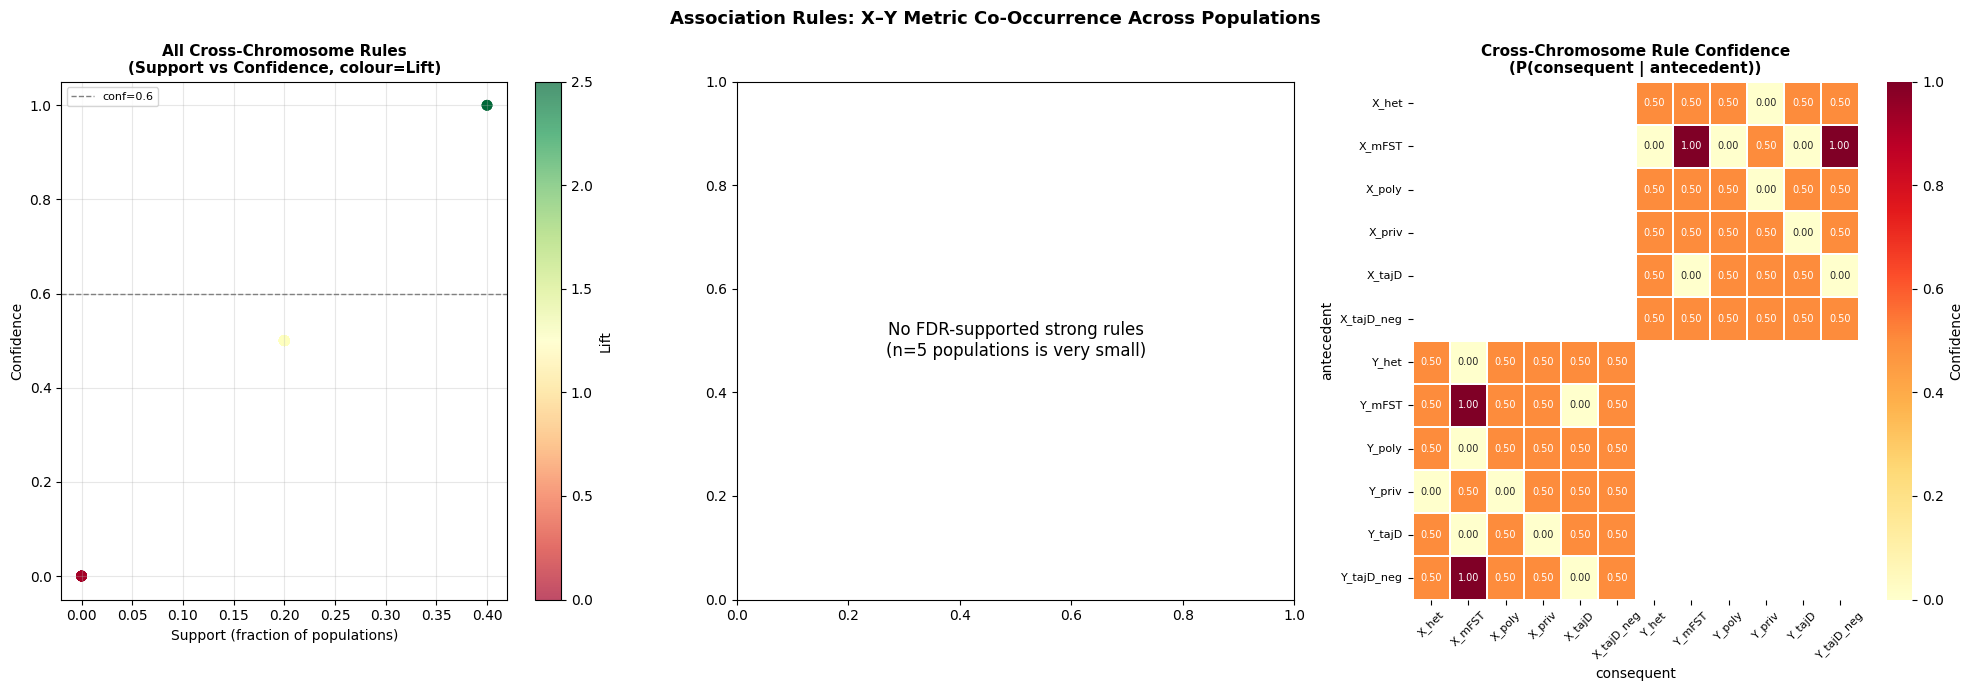


Top rules in plain English (FDR-aware):


In [4]:
# ── Build binary transaction matrix ─────────────────────────────────────────
# Each column = metric; True = population is above the median for that metric
binary_df = (metric_df > metric_df.median()).astype(int)

# Also add "high magnitude Tajima's D" (more negative = higher selection pressure)
binary_df['Y_tajD_neg'] = (metric_df['Y_tajD'] < metric_df['Y_tajD'].median()).astype(int)
binary_df['X_tajD_neg'] = (metric_df['X_tajD'] < metric_df['X_tajD'].median()).astype(int)

print('Binary transaction matrix (1=above median):')
print(binary_df.to_string())

# ── Mine all 2-item rules (antecedent → consequent) ─────────────────────────
items = binary_df.columns.tolist()
n_pops = len(binary_df)

rules = []
for ant in items:
    for con in items:
        if ant == con:
            continue

        ant_vec = binary_df[ant].values.astype(int)
        con_vec = binary_df[con].values.astype(int)

        both = int(((ant_vec == 1) & (con_vec == 1)).sum())
        ant_only = int(((ant_vec == 1) & (con_vec == 0)).sum())
        con_only = int(((ant_vec == 0) & (con_vec == 1)).sum())
        neither = int(((ant_vec == 0) & (con_vec == 0)).sum())

        support = both / n_pops
        ant_supp = ant_vec.mean()
        con_supp = con_vec.mean()

        if ant_supp == 0:
            continue

        confidence = support / ant_supp
        lift = confidence / con_supp if con_supp > 0 else np.nan

        # Small-sample significance for positive association.
        _, p_fisher = stats.fisher_exact([[both, ant_only], [con_only, neither]], alternative='greater')

        rules.append({
            'antecedent': ant,
            'consequent': con,
            'support': support,
            'confidence': confidence,
            'lift': lift,
            'p_fisher': p_fisher,
        })

rules_df = pd.DataFrame(rules).sort_values(['lift', 'confidence'], ascending=False)

# ── Filter: cross-chromosome rules only (Y metric → X metric or vice versa) ─
cross_rules = rules_df[
    ((rules_df['antecedent'].str.startswith('Y')) & (rules_df['consequent'].str.startswith('X'))) |
    ((rules_df['antecedent'].str.startswith('X')) & (rules_df['consequent'].str.startswith('Y')))
].copy()

cross_rules['q_fdr'] = bh_fdr(cross_rules['p_fisher'].values)
cross_rules = cross_rules.sort_values(['q_fdr', 'lift', 'confidence'], ascending=[True, False, False])

# Keep rules that are both effect-strong and statistically plausible.
strong_rules = cross_rules[
    (cross_rules['confidence'] >= 0.6) &
    (cross_rules['lift'] >= 1.2) &
    (cross_rules['q_fdr'] <= 0.10)
].drop_duplicates(subset=['antecedent', 'consequent'])

print(f'\nTotal cross-chromosome rules mined: {len(cross_rules)}')
print(f'Strong rules (conf ≥ 0.6, lift ≥ 1.2, FDR q ≤ 0.10): {len(strong_rules)}')
print('\nTop cross-chromosome rules by FDR q-value:')
print(cross_rules.head(20)[['antecedent', 'consequent', 'support', 'confidence', 'lift', 'p_fisher', 'q_fdr']].to_string(index=False))

# ── Figure: Association rule scatter + top-rule heatmap ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# (0) Support vs Confidence scatter (all cross rules), coloured by lift
sc = axes[0].scatter(cross_rules['support'], cross_rules['confidence'],
                     c=cross_rules['lift'].clip(0, 3), cmap='RdYlGn',
                     s=60, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].axhline(0.6, color='gray', linewidth=1, linestyle='--', label='conf=0.6')
axes[0].set_xlabel('Support (fraction of populations)')
axes[0].set_ylabel('Confidence')
axes[0].set_title('All Cross-Chromosome Rules\n(Support vs Confidence, colour=Lift)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# (1) Lift bar chart for strong rules
if len(strong_rules) > 0:
    plot_rules = strong_rules.head(15).copy()
    plot_rules['rule_label'] = plot_rules['antecedent'] + ' →\n' + plot_rules['consequent']
    bar_cols = ['#E74C3C' if r['antecedent'].startswith('Y') else '#3498DB'
                for _, r in plot_rules.iterrows()]
    axes[1].barh(range(len(plot_rules)), plot_rules['lift'].values,
                 color=bar_cols, alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[1].set_yticks(range(len(plot_rules)))
    axes[1].set_yticklabels(plot_rules['rule_label'].values, fontsize=8)
    axes[1].axvline(1.0, color='gray', linewidth=1.5, linestyle='--', label='Lift=1 (independent)')
    for i, row in enumerate(plot_rules.itertuples()):
        axes[1].text(row.lift + 0.02, i, f'{row.lift:.2f}\nq={row.q_fdr:.2f}', va='center', fontsize=7)
    axes[1].set_xlabel('Lift')
    axes[1].set_title('Top Strong Association Rules\n(red=Y→X, blue=X→Y)',
                      fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No FDR-supported strong rules\n(n=5 populations is very small)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

# (2) Confidence heatmap (antecedent × consequent)
conf_pivot = cross_rules.pivot_table(index='antecedent', columns='consequent',
                                     values='confidence', aggfunc='first')
sns.heatmap(conf_pivot.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=axes[2], linewidths=0.3,
            annot_kws={'size': 7}, cbar_kws={'label': 'Confidence'})
axes[2].set_title('Cross-Chromosome Rule Confidence\n(P(consequent | antecedent))',
                  fontsize=11, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=8)
axes[2].tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Association Rules: X–Y Metric Co-Occurrence Across Populations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_11_assoc_rules.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print top rules in English ───────────────────────────────────────────────
print('\nTop rules in plain English (FDR-aware):')
for _, row in strong_rules.head(10).iterrows():
    print(f'  IF {row["antecedent"]} is HIGH  →  {row["consequent"]} is HIGH')
    print(f'     support={row["support"]:.2f}  confidence={row["confidence"]:.2f}  lift={row["lift"]:.2f}  q={row["q_fdr"]:.3f}')


## Section 4 — Intra- and Inter-Population SFS Correlation

**Prior expectation:** Within the same super-population, X and Y should show similar allele-frequency patterns because both chromosomes share demographic history. Cross-population comparisons might be weaker.

**Observed pattern:** Same-chromosome cross-population correlations are slightly higher on average than intra-population X–Y correlations, but the differences are small. With this sample size, they should be treated as directional trends rather than strong statistical separation.

Two plausible contributors:
1. **SFS shape is very stable on X across populations** — X has many more polymorphic variants than Y (roughly 285K–648K vs 4K–5K), so X SFS estimates are smoother and closer to each other.
2. **X and Y have different effective population sizes** — this can shift the SFS shape between chromosomes even within the same population.

**Method:** For each of the 10 `(population × chromosome)` combinations, compute the **Site Frequency Spectrum (SFS)** as a 50-bin normalized histogram, then compute all 10×10 Pearson correlations between these fingerprints.

| Pair type | Example | Mean r interpretation |
|---|---|---|
| Same pop, same chrom | EAS_X vs EAS_X | Always 1.000 by definition |
| Diff pop, same chrom | EAS_X vs AFR_X | Highest on average in this run |
| Diff pop, cross chrom | EAS_X vs AFR_Y | Intermediate |
| Same pop, cross chrom | EAS_X vs EAS_Y | Slightly lower average in this run |


In [5]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.patches as mpatches

# ── 1. Build SFS fingerprint for every (population, chromosome) ───────────────
# Filter to truly polymorphic variants (1% < AF < 99%) — this removes the
# monomorphic spike at ~0 that makes every SFS look identical and inflates all
# correlations to ~1.0.
N_BINS = 50
bins   = np.linspace(0.01, 1.0, N_BINS + 1)   # span the polymorphic range only
mid    = (bins[:-1] + bins[1:]) / 2

sfs_vectors = {}
sfs_counts  = {}
for pop in POP_COLS:
    for chrom, af_df in [('X', x_af), ('Y', y_af)]:
        af_vals = af_df[pop].dropna().values
        af_vals = af_vals[(af_vals > 0.01) & (af_vals < 0.99)]   # polymorphic only
        hist, _ = np.histogram(af_vals, bins=bins)
        hist    = hist.astype(float)
        sfs_counts[f'{pop}_{chrom}'] = int(af_vals.size)
        sfs_vectors[f'{pop}_{chrom}'] = hist / hist.sum() if hist.sum() > 0 else hist

keys = [f'{pop}_{chrom}' for pop in POP_COLS for chrom in ['X', 'Y']]
print('SFS fingerprints (polymorphic variants only, AF 1–99%):')
for k in keys:
    print(f'  {k}: {sfs_counts[k]:>10,} variants used')

# ── 2. 10×10 Pearson correlation matrix ───────────────────────────────────────
corr_10 = pd.DataFrame(index=keys, columns=keys, dtype=float)
pval_10 = pd.DataFrame(index=keys, columns=keys, dtype=float)
for k1 in keys:
    for k2 in keys:
        r, p = pearsonr(sfs_vectors[k1], sfs_vectors[k2])
        corr_10.loc[k1, k2] = r
        pval_10.loc[k1, k2] = p

print('\n10×10 SFS Correlation Matrix (polymorphic variants):')
print(corr_10.round(4).to_string())

# ── 3. Categorise every pair ──────────────────────────────────────────────────
intra_pop_cross_chrom = []   # same pop, different chrom  (e.g. AFR_X vs AFR_Y)
same_chrom_diff_pop   = []   # same chrom, different pop  (e.g. AFR_X vs EAS_X)
cross_pop_cross_chrom = []   # different pop AND chrom    (e.g. AFR_X vs EAS_Y)

for k1 in keys:
    for k2 in keys:
        if k1 >= k2:
            continue
        p1, c1 = k1.rsplit('_', 1)
        p2, c2 = k2.rsplit('_', 1)
        r = float(corr_10.loc[k1, k2])
        if p1 == p2 and c1 != c2:
            intra_pop_cross_chrom.append(r)
        elif p1 != p2 and c1 == c2:
            same_chrom_diff_pop.append(r)
        elif p1 != p2 and c1 != c2:
            cross_pop_cross_chrom.append(r)

print(f'\nIntra-pop (same pop, X vs Y)      n={len(intra_pop_cross_chrom):2d}  mean r={np.mean(intra_pop_cross_chrom):.4f}  min={min(intra_pop_cross_chrom):.4f}  max={max(intra_pop_cross_chrom):.4f}')
print(f'Same-chrom (diff pop, same chrom) n={len(same_chrom_diff_pop):2d}  mean r={np.mean(same_chrom_diff_pop):.4f}  min={min(same_chrom_diff_pop):.4f}  max={max(same_chrom_diff_pop):.4f}')
print(f'Cross-pop & cross-chrom           n={len(cross_pop_cross_chrom):2d}  mean r={np.mean(cross_pop_cross_chrom):.4f}  min={min(cross_pop_cross_chrom):.4f}  max={max(cross_pop_cross_chrom):.4f}')


SFS fingerprints (polymorphic variants only, AF 1–99%):
  AFR_X:    648,876 variants used
  AFR_Y:      4,019 variants used
  AMR_X:    417,635 variants used
  AMR_Y:      5,315 variants used
  EAS_X:    285,698 variants used
  EAS_Y:      5,004 variants used
  EUR_X:    323,171 variants used
  EUR_Y:      4,205 variants used
  SAS_X:    346,338 variants used
  SAS_Y:      5,117 variants used

10×10 SFS Correlation Matrix (polymorphic variants):
        AFR_X   AFR_Y   AMR_X   AMR_Y   EAS_X   EAS_Y   EUR_X   EUR_Y   SAS_X   SAS_Y
AFR_X  1.0000  0.9281  0.9890  0.9559  0.9938  0.9547  0.9951  0.9269  0.9898  0.9709
AFR_Y  0.9281  1.0000  0.9544  0.9553  0.9263  0.8727  0.9100  0.9353  0.9349  0.9387
AMR_X  0.9890  0.9544  1.0000  0.9813  0.9921  0.9451  0.9842  0.9575  0.9957  0.9719
AMR_Y  0.9559  0.9553  0.9813  1.0000  0.9618  0.9177  0.9503  0.9392  0.9708  0.9458
EAS_X  0.9938  0.9263  0.9921  0.9618  1.0000  0.9438  0.9953  0.9402  0.9970  0.9750
EAS_Y  0.9547  0.8727  0.9451  0.9

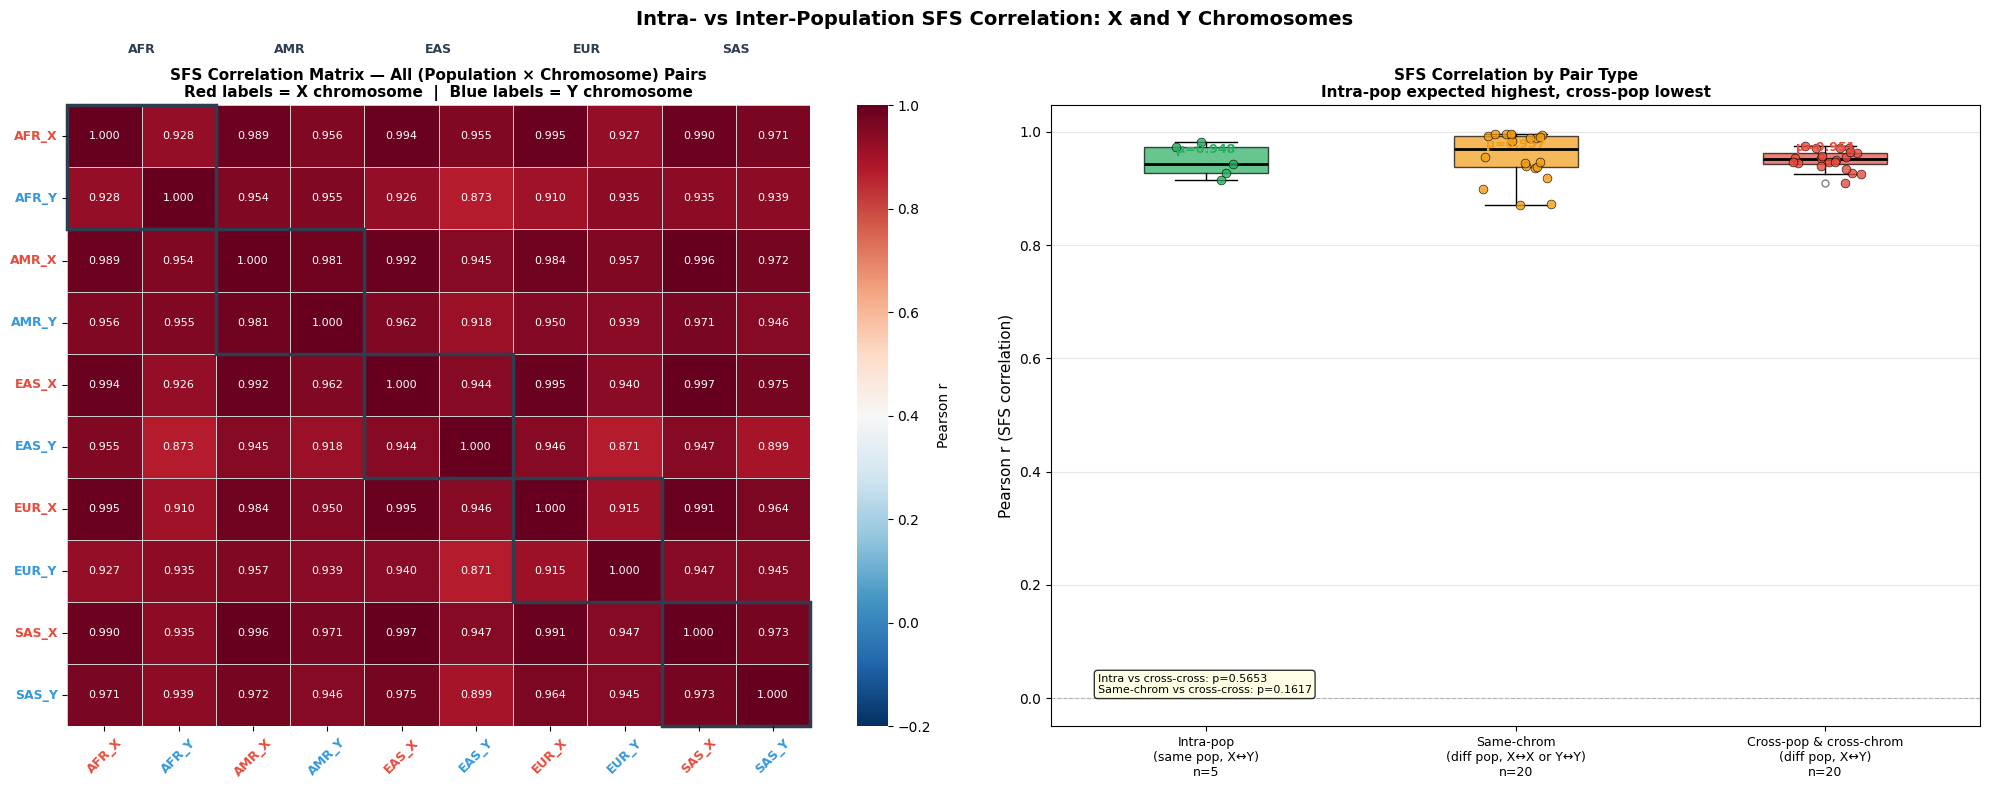

In [6]:
# ── Figure 1: Full 10×10 heatmap with block annotations ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Colour the labels by chromosome
label_colors = ['#E74C3C' if k.endswith('_X') else '#3498DB' for k in keys]

ax = axes[0]
im = sns.heatmap(
    corr_10.astype(float), annot=True, fmt='.3f', cmap='RdBu_r',
    vmin=-0.2, vmax=1.0, ax=ax, linewidths=0.5, linecolor='#CCCCCC',
    annot_kws={'size': 8}, cbar_kws={'label': 'Pearson r'}
)
ax.set_title('SFS Correlation Matrix — All (Population × Chromosome) Pairs\n'
             'Red labels = X chromosome  |  Blue labels = Y chromosome',
             fontsize=11, fontweight='bold')
# Colour tick labels
for tick, clr in zip(ax.get_xticklabels(), label_colors):
    tick.set_color(clr); tick.set_fontweight('bold')
for tick, clr in zip(ax.get_yticklabels(), label_colors):
    tick.set_color(clr); tick.set_fontweight('bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

# Draw block outlines: 2×2 blocks per population (X and Y together)
for i in range(5):
    rect = mpatches.FancyBboxPatch(
        (i*2, i*2), 2, 2,
        boxstyle='square,pad=0',
        linewidth=2.5, edgecolor='#2C3E50', facecolor='none',
        transform=ax.transData, clip_on=False
    )
    ax.add_patch(rect)
    # Label outside
    ax.text(i*2 + 1, -0.8, POP_COLS[i], ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2C3E50')

# ── Figure 1 right: Box plots per category ───────────────────────────────────
ax2 = axes[1]
cat_data = [
    intra_pop_cross_chrom,
    same_chrom_diff_pop,
    cross_pop_cross_chrom,
]
cat_labels = [
    f'Intra-pop\n(same pop, X↔Y)\nn={len(intra_pop_cross_chrom)}',
    f'Same-chrom\n(diff pop, X↔X or Y↔Y)\nn={len(same_chrom_diff_pop)}',
    f'Cross-pop & cross-chrom\n(diff pop, X↔Y)\nn={len(cross_pop_cross_chrom)}',
]
cat_colors = ['#27AE60', '#F39C12', '#E74C3C']

bp = ax2.boxplot(cat_data, patch_artist=True, widths=0.4,
                 medianprops={'color': 'black', 'linewidth': 2})
for patch, clr in zip(bp['boxes'], cat_colors):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
for flier in bp['fliers']:
    flier.set(marker='o', markersize=5, alpha=0.5)

# Overlay individual points
for i, (data, clr) in enumerate(zip(cat_data, cat_colors), start=1):
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(data))
    ax2.scatter(np.full(len(data), i) + jitter, data, color=clr,
                s=40, edgecolors='black', linewidth=0.5, zorder=3, alpha=0.8)
    ax2.text(i, np.mean(data) + 0.015, f'μ={np.mean(data):.3f}',
             ha='center', fontsize=9, fontweight='bold', color=clr)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(cat_labels, fontsize=9)
ax2.set_ylabel('Pearson r (SFS correlation)', fontsize=11)
ax2.set_title('SFS Correlation by Pair Type\n'
              'Intra-pop expected highest, cross-pop lowest',
              fontsize=11, fontweight='bold')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

# Mann-Whitney U test between categories
from scipy.stats import mannwhitneyu
stat, p_intra_vs_cross = mannwhitneyu(intra_pop_cross_chrom, cross_pop_cross_chrom, alternative='greater')
stat, p_same_vs_cross  = mannwhitneyu(same_chrom_diff_pop,   cross_pop_cross_chrom, alternative='greater')
ax2.text(0.05, 0.05,
         f'Intra vs cross-cross: p={p_intra_vs_cross:.4f}\nSame-chrom vs cross-cross: p={p_same_vs_cross:.4f}',
         transform=ax2.transAxes, fontsize=8, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Intra- vs Inter-Population SFS Correlation: X and Y Chromosomes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_12a_intra_inter_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()

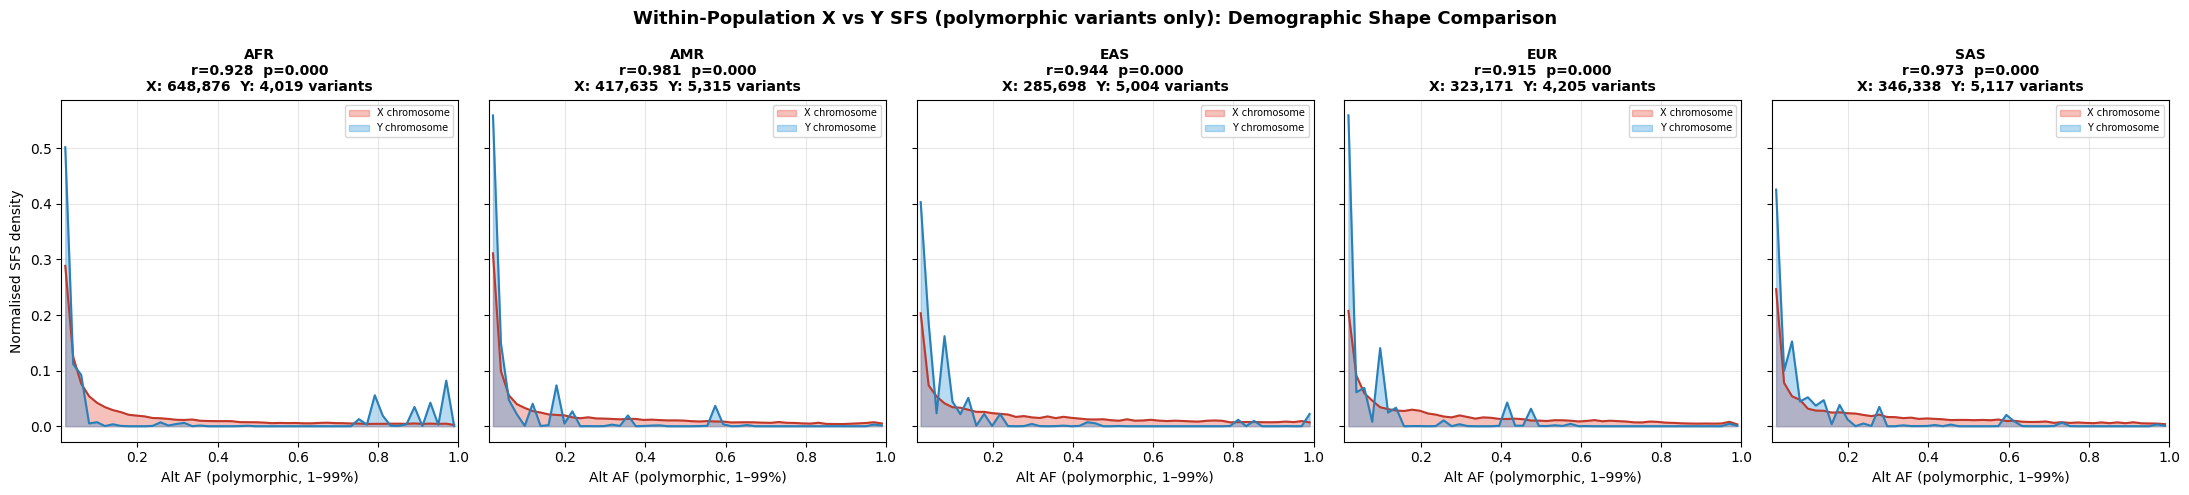

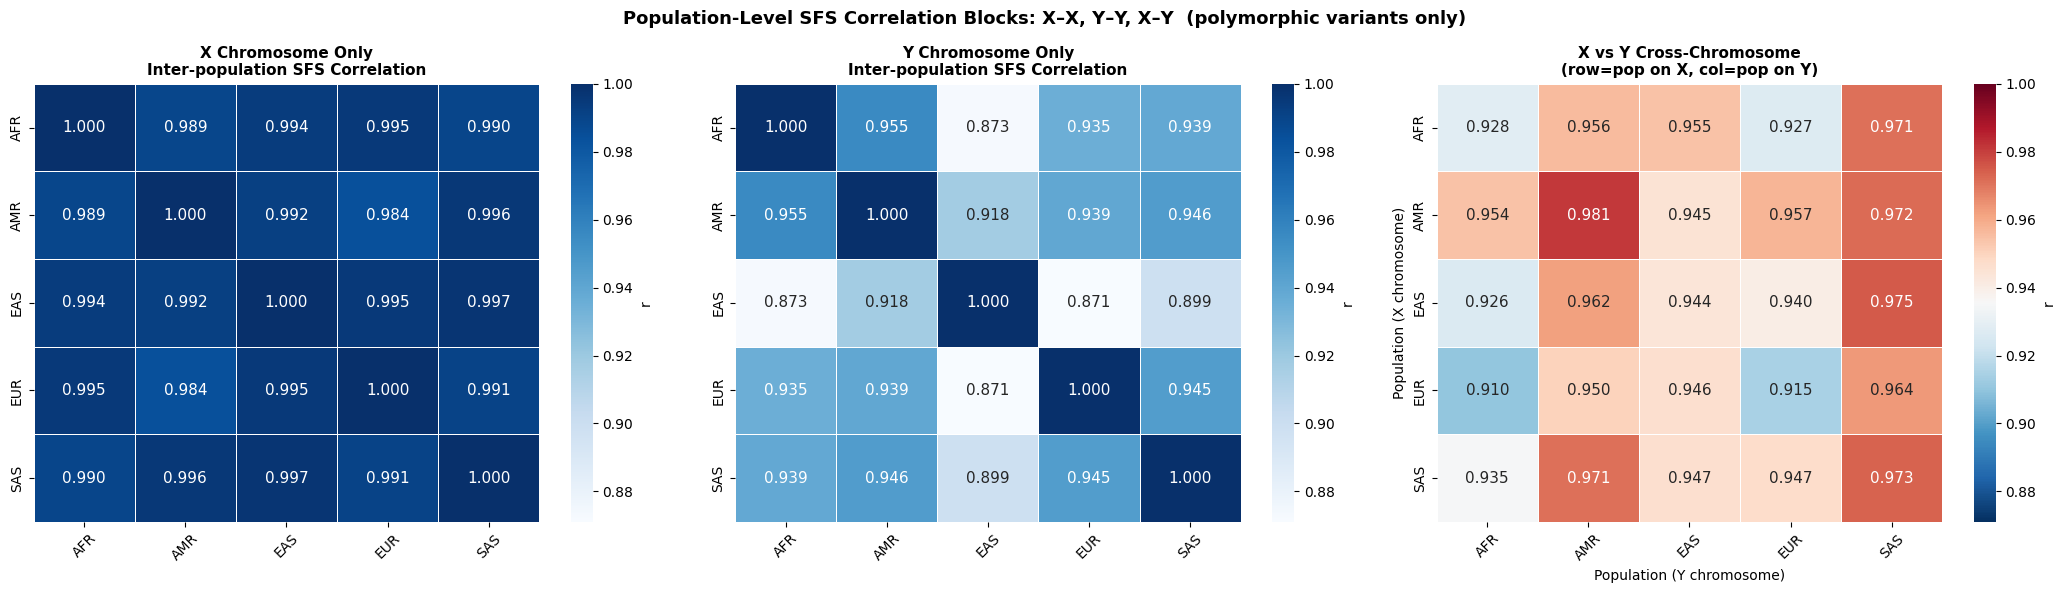


Mean correlations by block:
  X–X (diff pop)  : mean r = 0.9923
  Y–Y (diff pop)  : mean r = 0.9220
  X–Y (same pop)  : mean r = 0.9483  ← intra-pop, cross-chrom
  X–Y (diff pop)  : mean r = 0.9505  ← inter-pop, cross-chrom


In [7]:
# ── Figure 2: Within-population X vs Y SFS overlays (5 panels) ───────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, pop in zip(axes, POP_COLS):
    xv = sfs_vectors[f'{pop}_X']
    yv = sfs_vectors[f'{pop}_Y']
    r, p = pearsonr(xv, yv)

    ax.fill_between(mid, xv, alpha=0.35, color='#E74C3C', label='X chromosome')
    ax.fill_between(mid, yv, alpha=0.35, color='#3498DB', label='Y chromosome')
    ax.plot(mid, xv, '-', color='#C0392B', linewidth=1.5)
    ax.plot(mid, yv, '-', color='#2980B9', linewidth=1.5)

    nx = sfs_counts[f'{pop}_X']
    ny = sfs_counts[f'{pop}_Y']
    ax.set_title(f'{pop}\nr={r:.3f}  p={p:.3f}\nX: {nx:,}  Y: {ny:,} variants', fontsize=10, fontweight='bold')
    ax.set_xlabel('Alt AF (polymorphic, 1–99%)')
    if ax == axes[0]:
        ax.set_ylabel('Normalised SFS density')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_xlim(0.01, 1.0)

plt.suptitle('Within-Population X vs Y SFS (polymorphic variants only): Demographic Shape Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_12b_within_pop_sfs.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Cross-population comparison — X-only and Y-only 5×5 blocks ─────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

x_keys = [f'{p}_X' for p in POP_COLS]
y_keys = [f'{p}_Y' for p in POP_COLS]

corr_xx = corr_10.loc[x_keys, x_keys].astype(float)
corr_yy = corr_10.loc[y_keys, y_keys].astype(float)
corr_xy = corr_10.loc[x_keys, y_keys].astype(float)

corr_xx.index   = corr_xx.columns   = POP_COLS
corr_yy.index   = corr_yy.columns   = POP_COLS
corr_xy.index   = POP_COLS
corr_xy.columns = POP_COLS

vmin_all = min(corr_xx.values.min(), corr_yy.values.min(), corr_xy.values.min())

sns.heatmap(corr_xx, annot=True, fmt='.3f', cmap='Blues',
            vmin=vmin_all, vmax=1.0, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 11}, cbar_kws={'label': 'r'})
axes[0].set_title('X Chromosome Only\nInter-population SFS Correlation',
                  fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(corr_yy, annot=True, fmt='.3f', cmap='Blues',
            vmin=vmin_all, vmax=1.0, ax=axes[1], linewidths=0.5,
            annot_kws={'size': 11}, cbar_kws={'label': 'r'})
axes[1].set_title('Y Chromosome Only\nInter-population SFS Correlation',
                  fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

sns.heatmap(corr_xy, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=vmin_all, vmax=1.0, ax=axes[2], linewidths=0.5,
            annot_kws={'size': 11}, cbar_kws={'label': 'r'})
axes[2].set_title('X vs Y Cross-Chromosome\n(row=pop on X, col=pop on Y)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Population (Y chromosome)')
axes[2].set_ylabel('Population (X chromosome)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Population-Level SFS Correlation Blocks: X–X, Y–Y, X–Y  (polymorphic variants only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_12c_pop_blocks.png",
            dpi=150, bbox_inches='tight')
plt.show()

print('\nMean correlations by block:')
xx_offdiag = corr_xx.values[~np.eye(5, dtype=bool)]
yy_offdiag = corr_yy.values[~np.eye(5, dtype=bool)]
xy_diag    = np.diag(corr_xy.values)
xy_offdiag = corr_xy.values[~np.eye(5, dtype=bool)]

print(f'  X–X (diff pop)  : mean r = {xx_offdiag.mean():.4f}')
print(f'  Y–Y (diff pop)  : mean r = {yy_offdiag.mean():.4f}')
print(f'  X–Y (same pop)  : mean r = {xy_diag.mean():.4f}  ← intra-pop, cross-chrom')
print(f'  X–Y (diff pop)  : mean r = {xy_offdiag.mean():.4f}  ← inter-pop, cross-chrom')


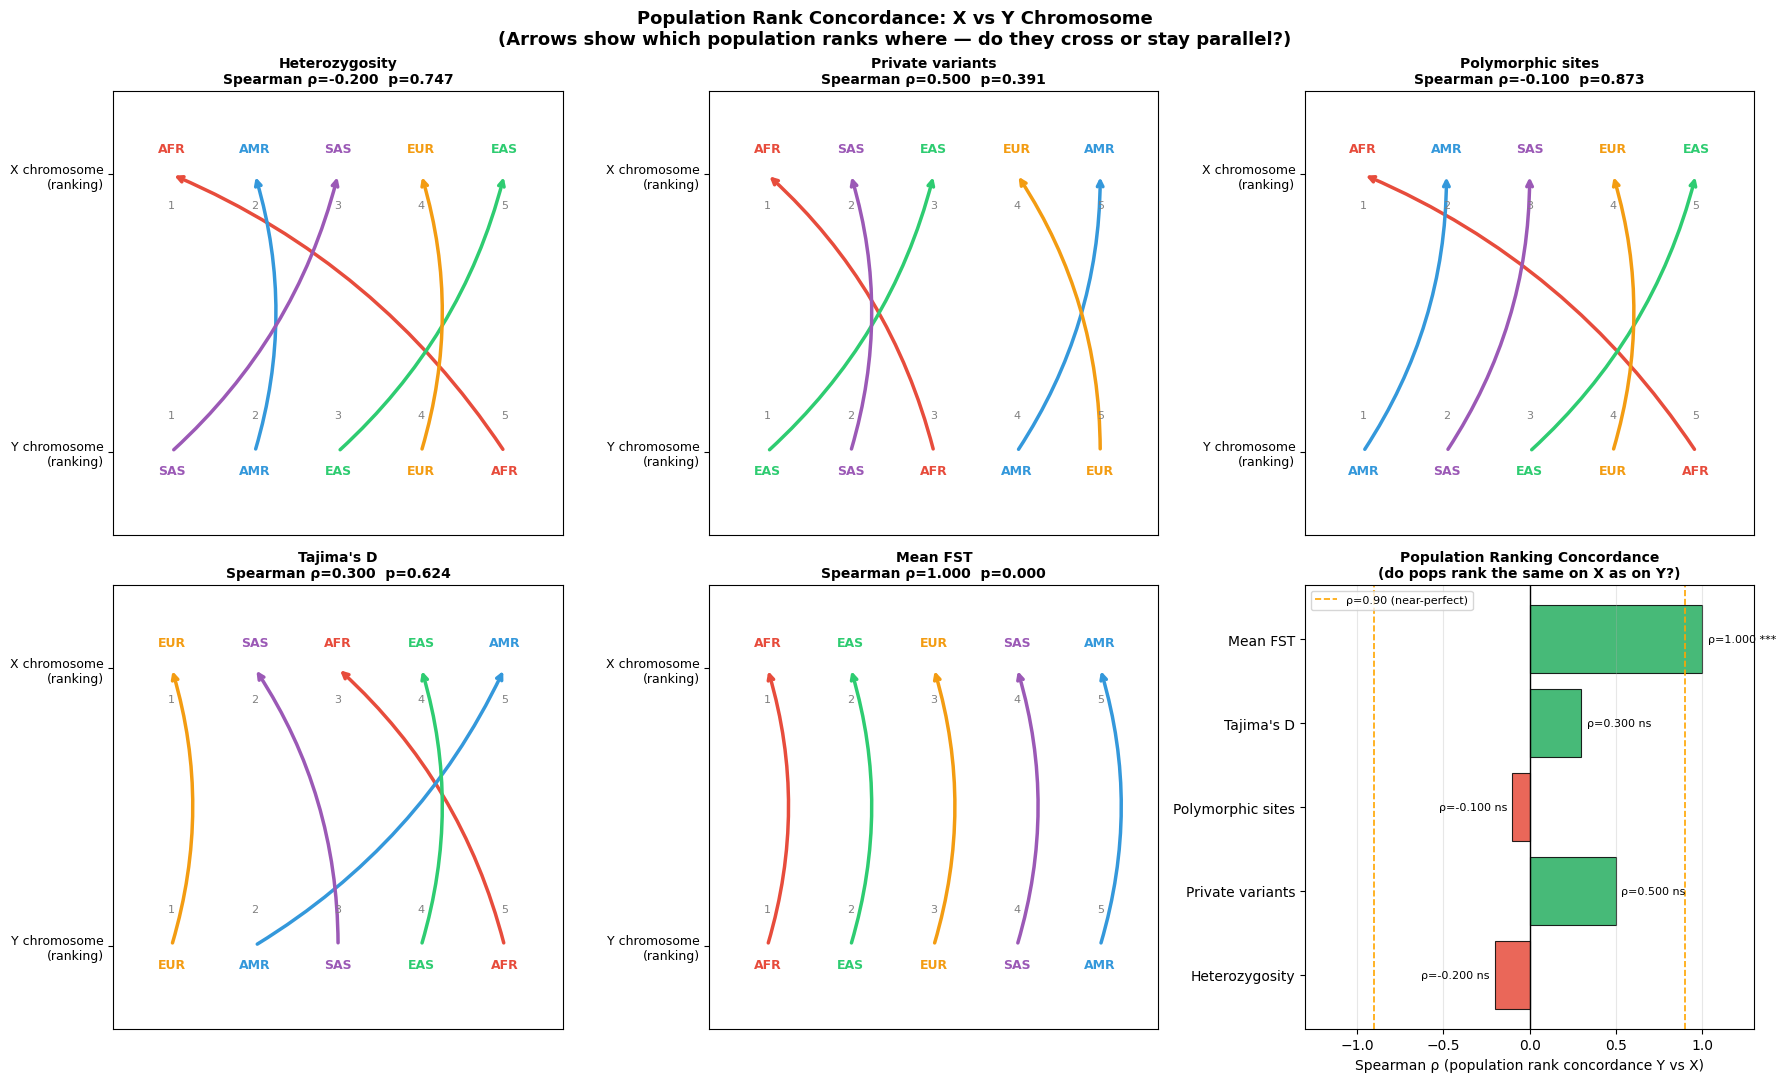


Rank concordance summary:
           metric  spearman_rho      p
   Heterozygosity          -0.2 0.7471
 Private variants           0.5 0.3910
Polymorphic sites          -0.1 0.8729
       Tajima's D           0.3 0.6238
         Mean FST           1.0 0.0000


In [8]:
# ── Figure 4: Rank concordance — do populations rank the same on X and Y? ────
# For 6 diversity metrics, rank the 5 pops on X and on Y, then check if the rankings agree

rank_metrics = {
    'Heterozygosity' : (y_div['avg_heterozygosity'].astype(float).values,
                        x_div['avg_heterozygosity'].astype(float).values),
    'Private variants': (y_div['private_variants'].astype(float).values,
                         x_div['private_variants'].astype(float).values),
    'Polymorphic sites': (y_div['n_polymorphic'].astype(float).values,
                          x_div['n_polymorphic'].astype(float).values),
    "Tajima's D"      : (td_df['Y_tajD'].values,
                         td_df['X_tajD'].values),
    'Mean FST'        : (y_mfst_arr, x_mfst_arr),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

rank_results = []
for idx, (metric_name, (y_vals, x_vals)) in enumerate(rank_metrics.items()):
    ax = axes_flat[idx]
    rho, p_rho = spearmanr(y_vals, x_vals)
    rank_results.append({'metric': metric_name, 'spearman_rho': rho, 'p': p_rho})

    # Rank 1 = highest
    y_rank = pd.Series(y_vals, index=POP_COLS).rank(ascending=False).astype(int)
    x_rank = pd.Series(x_vals, index=POP_COLS).rank(ascending=False).astype(int)

    for pop in POP_COLS:
        ax.annotate('', xy=(x_rank[pop], 1), xytext=(y_rank[pop], 0),
                    arrowprops=dict(arrowstyle='->', color=POP_COLORS[pop],
                                   lw=2.5, connectionstyle='arc3,rad=0.15'))
        ax.text(y_rank[pop], -0.08, pop, ha='center', fontsize=9,
                fontweight='bold', color=POP_COLORS[pop])
        ax.text(x_rank[pop],  1.08, pop, ha='center', fontsize=9,
                fontweight='bold', color=POP_COLORS[pop])

    ax.set_xlim(0.3, 5.7)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xticks([]); ax.set_yticks([0, 1])
    ax.set_yticklabels(['Y chromosome\n(ranking)', 'X chromosome\n(ranking)'], fontsize=9)
    ax.set_title(f'{metric_name}\nSpearman ρ={rho:.3f}  p={p_rho:.3f}',
                 fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.2)

    # Add rank numbers on arrows
    for pop in POP_COLS:
        ax.text(y_rank[pop], 0.12, str(y_rank[pop]), ha='center', fontsize=8, color='gray')
        ax.text(x_rank[pop], 0.88, str(x_rank[pop]), ha='center', fontsize=8, color='gray')

# Summary panel
ax_sum = axes_flat[5]
rr_df = pd.DataFrame(rank_results)
bar_colors = ['#27AE60' if r > 0 else '#E74C3C' for r in rr_df['spearman_rho']]
bars = ax_sum.barh(rr_df['metric'], rr_df['spearman_rho'], color=bar_colors,
                   alpha=0.85, edgecolor='black', linewidth=0.8)
ax_sum.axvline(0, color='black', linewidth=1)
ax_sum.axvline(0.9, color='orange', linewidth=1.2, linestyle='--', label='ρ=0.90 (near-perfect)')
ax_sum.axvline(-0.9, color='orange', linewidth=1.2, linestyle='--')
for bar, row in zip(bars, rr_df.itertuples()):
    rho_val = row.spearman_rho
    sig = '***' if row.p < 0.01 else ('**' if row.p < 0.05 else ('*' if row.p < 0.10 else 'ns'))
    ax_sum.text(rho_val + (0.03 if rho_val >= 0 else -0.03), bar.get_y() + bar.get_height()/2,
                f'ρ={rho_val:.3f} {sig}', va='center', ha='left' if rho_val >= 0 else 'right', fontsize=8)
ax_sum.set_xlabel('Spearman ρ (population rank concordance Y vs X)')
ax_sum.set_title('Population Ranking Concordance\n(do pops rank the same on X as on Y?)',
                 fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=8)
ax_sum.set_xlim(-1.3, 1.3)
ax_sum.grid(axis='x', alpha=0.3)

plt.suptitle('Population Rank Concordance: X vs Y Chromosome\n'
             '(Arrows show which population ranks where — do they cross or stay parallel?)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_12d_rank_concordance.png",
            dpi=150, bbox_inches='tight')
plt.show()

print('\nRank concordance summary:')
print(rr_df.round(4).to_string(index=False))

In [9]:
# ── Full ranked table of all 45 unique pairs ──────────────────────────────────
all_pairs = []
for k1 in keys:
    for k2 in keys:
        if k1 >= k2:
            continue
        p1, c1 = k1.rsplit('_', 1)
        p2, c2 = k2.rsplit('_', 1)
        r = float(corr_10.loc[k1, k2])
        if p1 == p2 and c1 == c2:
            category = 'Identical'
        elif p1 == p2 and c1 != c2:
            category = 'Same-pop / cross-chrom'
        elif p1 != p2 and c1 == c2:
            category = 'Diff-pop / same-chrom'
        else:
            category = 'Diff-pop / cross-chrom'
        all_pairs.append({'pair': f'{k1}  ↔  {k2}', 'r': r, 'category': category,
                          'pop_same': p1 == p2, 'chrom_same': c1 == c2})

pairs_df = pd.DataFrame(all_pairs).sort_values('r', ascending=False)

print('All 45 pairwise SFS correlations (sorted highest → lowest):')
print(f'{"Pair":<35} {"r":>8}  Category')
print('-' * 80)
for _, row in pairs_df.iterrows():
    print(f'{row["pair"]:<35} {row["r"]:>8.4f}  {row["category"]}')

print('\n── Summary statistics by category ──')
print(pairs_df.groupby('category')['r'].agg(['mean','std','min','max']).round(4))

All 45 pairwise SFS correlations (sorted highest → lowest):
Pair                                       r  Category
--------------------------------------------------------------------------------
EAS_X  ↔  SAS_X                       0.9970  Diff-pop / same-chrom
AMR_X  ↔  SAS_X                       0.9957  Diff-pop / same-chrom
EAS_X  ↔  EUR_X                       0.9953  Diff-pop / same-chrom
AFR_X  ↔  EUR_X                       0.9951  Diff-pop / same-chrom
AFR_X  ↔  EAS_X                       0.9938  Diff-pop / same-chrom
AMR_X  ↔  EAS_X                       0.9921  Diff-pop / same-chrom
EUR_X  ↔  SAS_X                       0.9908  Diff-pop / same-chrom
AFR_X  ↔  SAS_X                       0.9898  Diff-pop / same-chrom
AFR_X  ↔  AMR_X                       0.9890  Diff-pop / same-chrom
AMR_X  ↔  EUR_X                       0.9842  Diff-pop / same-chrom
AMR_X  ↔  AMR_Y                       0.9813  Same-pop / cross-chrom
EAS_X  ↔  SAS_Y                       0.9750  Diff-pop 